In [7]:
# Imports 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Make default plots a little nicer
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

print('Libraries installed successfully!')

Libraries installed successfully!


In [3]:
teams_df = pd.read_csv('../data/Teams.csv')

print(f'Loaded {len(teams_df)} team-seasons')
print('Columns:', teams_df.columns.tolist())
print('\nFirst 5 rows:')
print(teams_df.tail())

Loaded 3614 team-seasons
Columns: ['yearID', 'lgID', 'teamID', 'franchID', 'divID', 'Rank', 'G', 'Ghome', 'W', 'L', 'DivWin', 'WCWin', 'LgWin', 'WSWin', 'R', 'AB', 'H', '2B', '3B', 'HR', 'BB', 'SO', 'SB', 'CS', 'HBP', 'SF', 'RA', 'ER', 'ERA', 'CG', 'SHO', 'SV', 'IPouts', 'HA', 'HRA', 'BBA', 'SOA', 'E', 'DP', 'FP', 'name', 'park', 'attendance', 'BPF', 'PPF', 'teamIDBR', 'teamIDlahman45', 'teamIDretro']

First 5 rows:
      yearID lgID teamID franchID divID  Rank    G  Ghome   W   L  ...     DP  \
3609    2025   NL    SLN      STL     C     4  162   81.0  78  84  ...  124.0   
3610    2025   AL    TBA      TBD     E     4  162   81.0  77  85  ...  147.0   
3611    2025   AL    TEX      TEX     W     3  162   81.0  81  81  ...  122.0   
3612    2025   AL    TOR      TOR     E     1  162   81.0  94  68  ...  118.0   
3613    2025   NL    WAS      WSN     E     5  162   81.0  66  96  ...  131.0   

         FP                  name                 park  attendance    BPF  \
3609  0.987   St

In [5]:
# Going to clean and filter to modernish eras only

teams_df['win_pct'] = teams_df['W'] / teams_df['G']
modern_df = teams_df[teams_df['yearID']>= 1990].copy()

print(f'Filtered to modern era teams: {len(modern_df)} team seasons')
print(f'Years covered:', sorted(modern_df['yearID'].unique()))

# Basic Summary of our target
print('\nWin Percentage summary:')
print(modern_df['win_pct'].describe())

# Check for missing values in key columns
key_cols = ['W', 'L', 'R', 'RA', 'ERA', 'HR', 'BB', 'SO', 'attendance']
print("\nMissing values in key columns:")
print(modern_df[key_cols].isnull().sum())



Filtered to modern era teams: 1058 team seasons
Years covered: [np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Win Percentage summary:
count    1058.000000
mean        0.499910
std         0.073086
min         0.253086
25%         0.447853
50%         0.500000
75%         0.555556
max         0.716667
Name: win_pct, dtype: float64

Missing values in key columns:
W             0
L             0
R             0
RA            0
ERA           0
HR            0
BB       

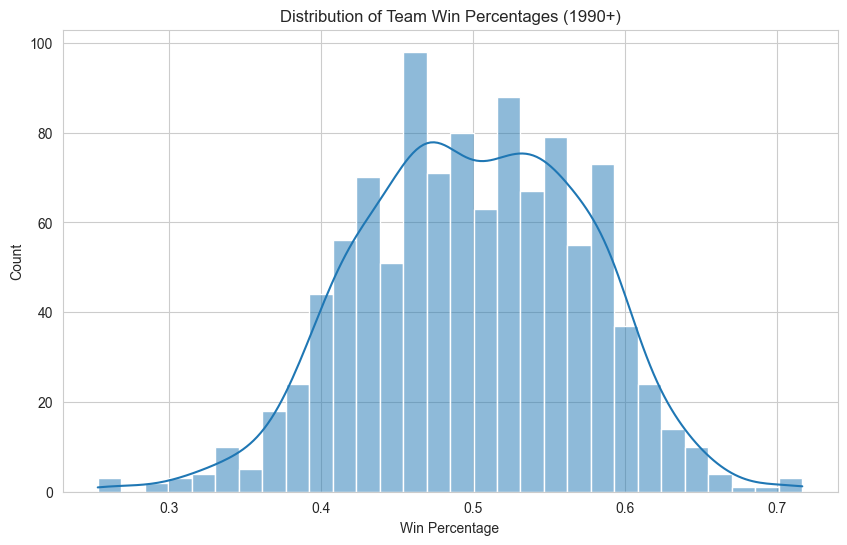

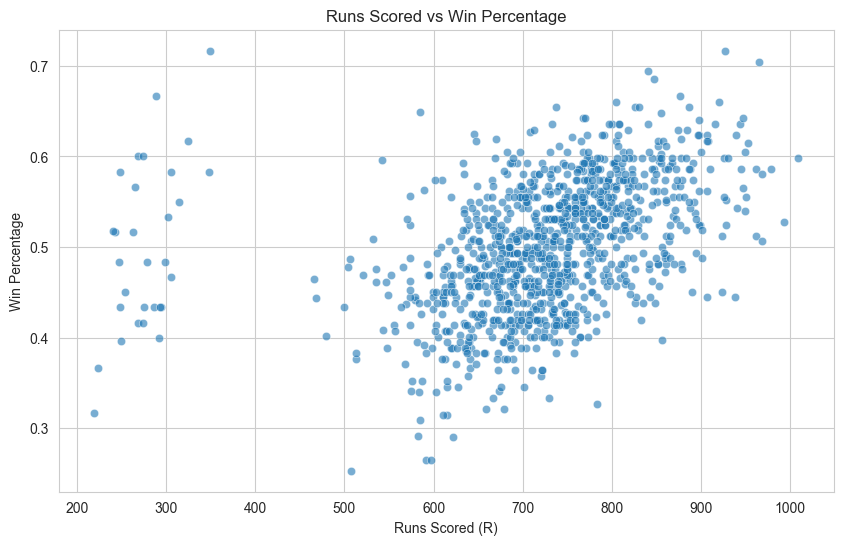

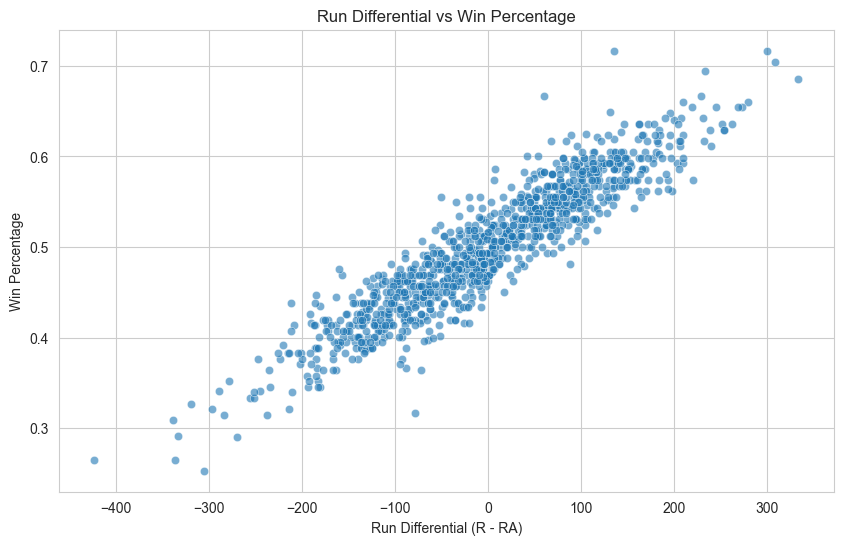

In [6]:
# Cell 11: Quick exploratory plots
import matplotlib.pyplot as plt
import seaborn as sns

# Win percentage distribution
plt.figure(figsize=(10, 6))
sns.histplot(modern_df['win_pct'], bins=30, kde=True)
plt.title('Distribution of Team Win Percentages (1990+)')
plt.xlabel('Win Percentage')
plt.show()

# Correlation between runs scored/allowed and wins
plt.figure(figsize=(10, 6))
sns.scatterplot(data=modern_df, x='R', y='win_pct', alpha=0.6)
plt.title('Runs Scored vs Win Percentage')
plt.xlabel('Runs Scored (R)')
plt.ylabel('Win Percentage')
plt.show()

# Run differential is usually very predictive
modern_df['run_diff'] = modern_df['R'] - modern_df['RA']
plt.figure(figsize=(10, 6))
sns.scatterplot(data=modern_df, x='run_diff', y='win_pct', alpha=0.6)
plt.title('Run Differential vs Win Percentage')
plt.xlabel('Run Differential (R - RA)')
plt.ylabel('Win Percentage')
plt.show()

In [8]:
# Feature Engineering

# Core features we'll use
modern_df['run_diff'] = modern_df['R'] - modern_df['RA']
modern_df['run_ratio'] = modern_df['R'] / modern_df['RA']   # Pythagorean-like

# Park-adjusted stats (simple version)
modern_df['R_per_game'] = modern_df['R'] / modern_df['G']
modern_df['RA_per_game'] = modern_df['RA'] / modern_df['G']

# Basic pitching and hitting strength
modern_df['offense_score'] = modern_df['R'] / modern_df['G']      # runs per game
modern_df['defense_score'] = modern_df['RA'] / modern_df['G']     # runs allowed per game

# Log transform for some skewed features (optional but good practice)
modern_df['log_attendance'] = np.log1p(modern_df['attendance'])

print("✅ New features created")
print("Current features shape:", modern_df.shape)
print("\nSample of new features:")
print(modern_df[['yearID', 'teamID', 'win_pct', 'run_diff', 'run_ratio', 
                 'offense_score', 'defense_score']].head())

✅ New features created
Current features shape: (1058, 56)

Sample of new features:
      yearID teamID   win_pct  run_diff  run_ratio  offense_score  \
2556    1990    ATL  0.401235    -139.0   0.830694       4.209877   
2557    1990    BAL  0.472050     -29.0   0.958453       4.155280   
2558    1990    BOS  0.543210      35.0   1.052711       4.314815   
2559    1990    CAL  0.493827     -16.0   0.977337       4.259259   
2560    1990    CHA  0.580247      49.0   1.077409       4.209877   

      defense_score  
2556       5.067901  
2557       4.335404  
2558       4.098765  
2559       4.358025  
2560       3.907407  


In [ ]:
# Prepare data for modeling

from sklearn.model_selection import train_test_split

# Features we will use for baseline model
feature_cols = ['run_diff', 'run_ratio', 'R_per_game', 'RA_per_game', 
                'offense_score', 'defense_score', 'G', 'HR', 'BB', 'SO', 
                'ERA', 'SV', 'log_attendance']

X = modern_df[feature_cols]
y = modern_df['win_pct']

# Time-based split: train on earlier years, test on later years
train_years = modern_df['yearID'] < 2020
test_years = modern_df['yearID'] >= 2020

X_train = X[train_years]
y_train = y[train_years]
X_test = X[test_years]
y_test = y[test_years]

print(f"Training set: {len(X_train)} team-seasons (years < 2020)")
print(f"Test set: {len(X_test)} team-seasons (years 2020+)")
print(f"Features used: {feature_cols}")

Training set: 878 team-seasons (years < 2020)
Test set: 180 team-seasons (years 2020+)
Features used: ['run_diff', 'run_ratio', 'R_per_game', 'RA_per_game', 'offense_score', 'defense_score', 'G', 'HR', 'BB', 'SO', 'ERA', 'SV', 'log_attendance']


In [10]:
# Train a baseline XGBoost model

import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='rmse'
)

model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=== Baseline Model Performance ===")
print(f"MAE:  {mae:.4f}  (average error in win percentage)")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# Compare to naive baseline (always predict mean win %)
mean_win_pct = y_train.mean()
naive_pred = np.full_like(y_test, mean_win_pct)
naive_mae = mean_absolute_error(y_test, naive_pred)
print(f"\nNaive baseline MAE (predict mean): {naive_mae:.4f}")

=== Baseline Model Performance ===
MAE:  0.0211  (average error in win percentage)
RMSE: 0.0281
R²:   0.8846

Naive baseline MAE (predict mean): 0.0661


Going to quickly explain what these numbers mean for the baseline model:
1) On average, our model is only off aroun ~0.0211 in win percentage, which is actually quite good for a baseline model. That equates to 3-4 games off in a 162 game season
2) RMSE of .0281 tells us that bigger errors get penalized slightly more than normal, but it is not horrible
3) $R^2$ of .8846 just means our model explains around 88.5% of the varience in team win percentage. Which is actually pretty good since we have only used run based features so far for the inputs
4) The naive baseline MAE showing .0661 tells us that our baseline model is 3x better than just guessing the average win rate for teams.

SHAP values computed successfully


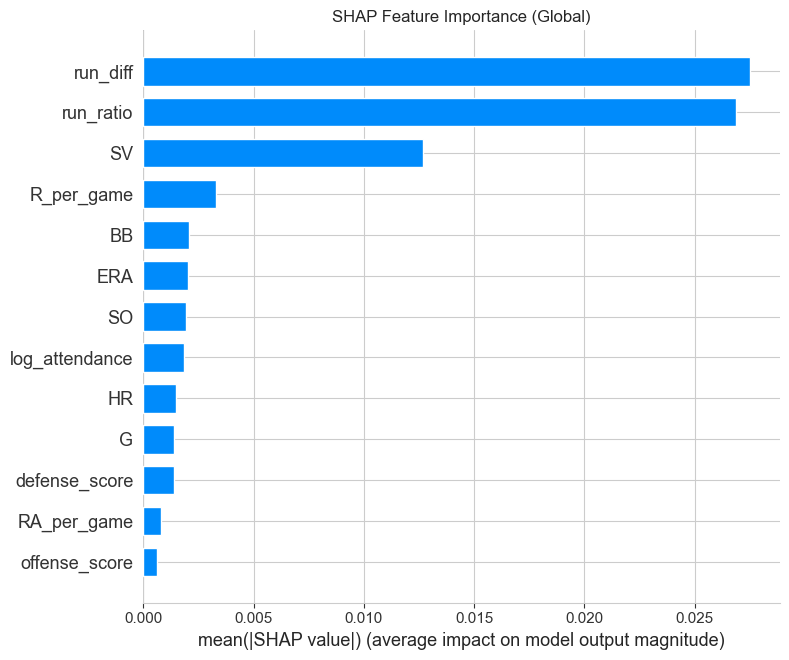

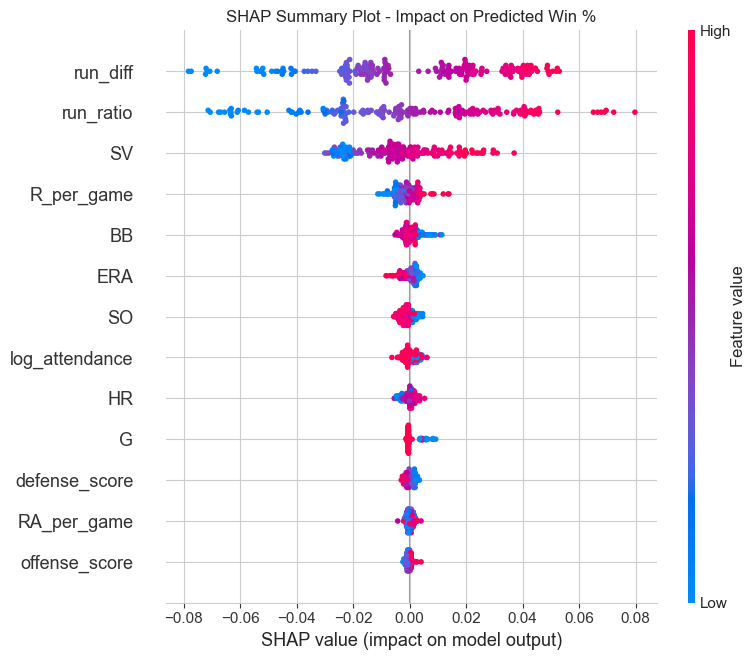

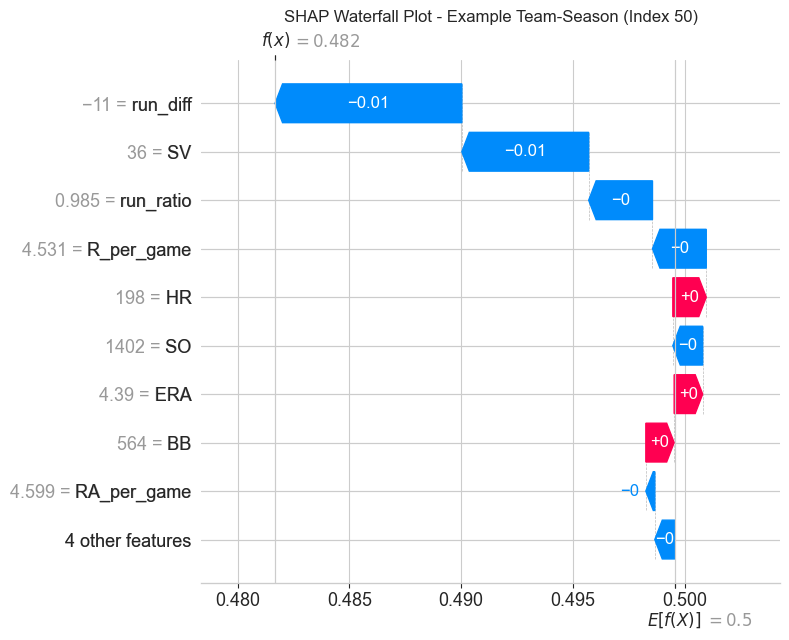

In [12]:
# SHAP Explanations (Global + Local)

import shap
import matplotlib.pyplot as plt

# Create SHAP explainer for tree-based model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values on the test set
shap_values = explainer.shap_values(X_test)

print("SHAP values computed successfully")

# 1. Global Summary Plot - Which features matter most overall?
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Global)")
plt.tight_layout()
plt.show()

# 2. Detailed Summary Plot (shows direction of impact)
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot - Impact on Predicted Win %")
plt.tight_layout()
plt.show()

# 3. Example of one specific team-season (local explanation)
sample_idx = 50
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[sample_idx],
    feature_names=X_test.columns.tolist()
), show=False)
plt.title(f"SHAP Waterfall Plot - Example Team-Season (Index {sample_idx})")
plt.tight_layout()
plt.show()